# **Завантаження даних**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q gdown

In [3]:
!gdown --id 14K-mX-Aqqk8cNdTmZHEmMVf7y4wtuSxJ --output animals10.zip

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=14K-mX-Aqqk8cNdTmZHEmMVf7y4wtuSxJ
From (redirected): https://drive.google.com/uc?id=14K-mX-Aqqk8cNdTmZHEmMVf7y4wtuSxJ&confirm=t&uuid=521122ab-ac13-40f5-be51-9e2cf64102fb
To: /content/animals10.zip
100% 614M/614M [00:07<00:00, 83.8MB/s]


In [4]:
!unzip -q animals10.zip -d ./animals10

In [5]:
# import shutil
# import os

# root_dir = '/content/animals10/'

# for item in os.listdir(root_dir):
#     item_path = os.path.join(root_dir, item)

#     try:
#         if os.path.isfile(item_path) or os.path.islink(item_path):
#             os.unlink(item_path)
#         elif os.path.isdir(item_path):
#             shutil.rmtree(item_path)
#     except Exception as e:
#         print(f"Помилка при видаленні {item_path}: {e}")


In [6]:
data_dir = './animals10/raw-img'

translate = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}

In [7]:
import os

for italian, english in translate.items():
    src = os.path.join(data_dir, italian)
    dst = os.path.join(data_dir, english)

    if os.path.exists(src):
        os.rename(src, dst)

In [8]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


data = datasets.ImageFolder(data_dir, transform=transform)

In [9]:
import numpy as np
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

labels = np.array(data.targets)

train_val_idx, test_idx = train_test_split(
    np.arange(len(data)), test_size=0.2, random_state=42, shuffle=True, stratify=labels
)

train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.25, random_state=42, shuffle=True, stratify=labels[train_val_idx]
)

train_data = Subset(data, train_idx)
val_data = Subset(data, val_idx)
test_data = Subset(data, test_idx)

In [10]:
print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

Train size: 15707
Validation size: 5236
Test size: 5236


In [11]:
from torch.utils.data import DataLoader

batch_size = 32
num_workers = 2

train_loader = DataLoader(
    train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers
)

val_loader = DataLoader(
    val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

test_loader = DataLoader(
    test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

In [12]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [13]:
train_loader.dataset.transform = train_transform
val_loader.dataset.transform = val_test_transform
test_loader.dataset.transform = val_test_transform

# **Визначення структур моделей**

In [15]:
import torch
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

CNN потрібна для завантаження моделей з попереднього завдання

In [43]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv5 = nn.Conv2d(256, 512, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.relu5 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(2, 2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(512, 256)
        self.relu_fc1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(256, 128)
        self.relu_fc2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.pool3(x)

        x = self.conv5(x)
        x = self.bn5(x)
        x = self.relu5(x)
        x = self.pool4(x)

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = self.relu_fc1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu_fc2(x)
        x = self.dropout2(x)

        x = self.fc3(x)

        return x

In [16]:
import torch
import torch.nn as nn

class CNN5(nn.Module):
    def __init__(self, fc1_units=256, fc2_units=128, dropout=0.2):
        super(CNN5, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv5 = nn.Conv2d(256, 512, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.relu5 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(2, 2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(512, fc1_units)
        self.relu_fc1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(fc1_units, fc2_units)
        self.relu_fc2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(fc2_units, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.relu3(self.bn3(self.conv3(x)))
        x = self.pool3(self.relu4(self.bn4(self.conv4(x))))
        x = self.pool4(self.relu5(self.bn5(self.conv5(x))))
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout1(self.relu_fc1(self.fc1(x)))
        x = self.dropout2(self.relu_fc2(self.fc2(x)))
        x = self.fc3(x)
        return x

In [17]:
class CNN3(nn.Module):
    def __init__(self, fc1_units=256, fc2_units=128, dropout=0.2):
        super(CNN3, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(128, fc1_units)
        self.relu_fc1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(fc1_units, fc2_units)
        self.relu_fc2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(fc2_units, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout1(self.relu_fc1(self.fc1(x)))
        x = self.dropout2(self.relu_fc2(self.fc2(x)))
        x = self.fc3(x)
        return x

In [25]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    # epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc

In [19]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc, epoch_f1

In [30]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test_evaluate(model, loader, criterion, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)

            total_loss += loss.item() * inputs.size(0)
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    avg_loss = total_loss / total

    return avg_loss, acc, f1


Параметри, на комбінаціях яких буде проходити тестування

In [27]:
import itertools

learning_rates = [0.01, 0.001, 0.0001]
dropouts = [0.2]
fc1_units_list = [128, 256]
fc2_units_list = [64, 128]
cnn_classes = {'CNN3': CNN3, 'CNN5': CNN5}

combinations = list(itertools.product(
    learning_rates, dropouts, fc1_units_list, fc2_units_list, cnn_classes.items()
))
combinations

[(0.01, 0.2, 128, 64, ('CNN3', __main__.CNN3)),
 (0.01, 0.2, 128, 64, ('CNN5', __main__.CNN5)),
 (0.01, 0.2, 128, 128, ('CNN3', __main__.CNN3)),
 (0.01, 0.2, 128, 128, ('CNN5', __main__.CNN5)),
 (0.01, 0.2, 256, 64, ('CNN3', __main__.CNN3)),
 (0.01, 0.2, 256, 64, ('CNN5', __main__.CNN5)),
 (0.01, 0.2, 256, 128, ('CNN3', __main__.CNN3)),
 (0.01, 0.2, 256, 128, ('CNN5', __main__.CNN5)),
 (0.001, 0.2, 128, 64, ('CNN3', __main__.CNN3)),
 (0.001, 0.2, 128, 64, ('CNN5', __main__.CNN5)),
 (0.001, 0.2, 128, 128, ('CNN3', __main__.CNN3)),
 (0.001, 0.2, 128, 128, ('CNN5', __main__.CNN5)),
 (0.001, 0.2, 256, 64, ('CNN3', __main__.CNN3)),
 (0.001, 0.2, 256, 64, ('CNN5', __main__.CNN5)),
 (0.001, 0.2, 256, 128, ('CNN3', __main__.CNN3)),
 (0.001, 0.2, 256, 128, ('CNN5', __main__.CNN5)),
 (0.0001, 0.2, 128, 64, ('CNN3', __main__.CNN3)),
 (0.0001, 0.2, 128, 64, ('CNN5', __main__.CNN5)),
 (0.0001, 0.2, 128, 128, ('CNN3', __main__.CNN3)),
 (0.0001, 0.2, 128, 128, ('CNN5', __main__.CNN5)),
 (0.0001, 0.2,

In [28]:
len(combinations)

24

Метод ручного пошуку найкращих параметрів

In [23]:
import pandas as pd

results = []

all_histories = []

def run_hparam_search(combinations, train_loader, val_loader, test_loader, epochs, device):
    best_f1 = -1
    best_model_info = None

    for i, (lr, dropout, fc1, fc2, (model_name, Model)) in enumerate(combinations):
        print(f"\nМодель {i+1}/{len(combinations)}: "
              f"Arch={model_name}, lr={lr}, dropout={dropout}, fc1={fc1}, fc2={fc2}")

        model = Model(fc1_units=fc1, fc2_units=fc2, dropout=dropout).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        train_losses, val_losses = [], []
        train_accuracies, val_accuracies = [], []
        val_f1_scores = []

        for epoch in range(epochs):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accuracies.append(train_acc)
            val_accuracies.append(val_acc)
            val_f1_scores.append(val_f1)

            print(f"Epoch [{epoch+1}/{epochs}] — "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

        test_loss, test_acc, test_f1 = test_evaluate(model, test_loader, criterion, device)
        print(f"Test — Loss: {test_loss:.4f}, Acc: {test_acc:.4f}, F1: {test_f1:.4f}")

        all_histories.append({
            'model_index': i,
            'model_name': model_name,
            'params': (lr, dropout, fc1, fc2),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies,
            'val_accuracies': val_accuracies,
            'val_f1s': val_f1_scores
        })

        results.append({
            'Model': model_name,
            'lr': lr,
            'dropout': dropout,
            'fc1': fc1,
            'fc2': fc2,
            'val_acc': val_accuracies[-1],
            'val_f1': val_f1_scores[-1],
            'test_acc': test_acc,
            'test_f1': test_f1
        })

        if val_f1_scores[-1] > best_f1:
            best_f1 = val_f1_scores[-1]
            best_model_info = results[-1]

    return pd.DataFrame(results), all_histories, best_model_info


In [31]:
df_results, histories, best_model = run_hparam_search(
    combinations=combinations,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    epochs=10,
    device=device
)

print("Найкраща модель:")
print(best_model)


Модель 1/24: Arch=CNN3, lr=0.01, dropout=0.2, fc1=128, fc2=64
Epoch [1/10] — Train Loss: 2.1278, Acc: 0.2374 | Val Loss: 2.1245, Acc: 0.2494, F1: 0.1552
Epoch [2/10] — Train Loss: 2.0556, Acc: 0.2604 | Val Loss: 2.0345, Acc: 0.2685, F1: 0.2119
Epoch [3/10] — Train Loss: 2.0217, Acc: 0.2711 | Val Loss: 1.9383, Acc: 0.3096, F1: 0.2280
Epoch [4/10] — Train Loss: 1.9721, Acc: 0.2934 | Val Loss: 1.9194, Acc: 0.3071, F1: 0.2343
Epoch [5/10] — Train Loss: 1.9372, Acc: 0.3079 | Val Loss: 1.8621, Acc: 0.3463, F1: 0.2974
Epoch [6/10] — Train Loss: 1.9023, Acc: 0.3283 | Val Loss: 1.8361, Acc: 0.3541, F1: 0.2815
Epoch [7/10] — Train Loss: 1.8558, Acc: 0.3422 | Val Loss: 1.7718, Acc: 0.3824, F1: 0.3042
Epoch [8/10] — Train Loss: 1.8092, Acc: 0.3575 | Val Loss: 1.7379, Acc: 0.3879, F1: 0.3302
Epoch [9/10] — Train Loss: 1.7514, Acc: 0.3753 | Val Loss: 1.5992, Acc: 0.4366, F1: 0.3837
Epoch [10/10] — Train Loss: 1.7003, Acc: 0.3904 | Val Loss: 1.6430, Acc: 0.4219, F1: 0.3441
Test — Loss: 1.6518, Acc: 

Збереження даних

In [32]:
df_results.to_csv('results.csv', index=False)

In [33]:
import pandas as pd
import pickle

flat_rows = []
for hist in all_histories:
    row = {
        'model_index': hist['model_index'],
        'model_name': hist['model_name'],
        'lr': hist['params'][0],
        'dropout': hist['params'][1],
        'fc1': hist['params'][2],
        'fc2': hist['params'][3],
        'final_train_loss': hist['train_losses'][-1],
        'final_val_loss': hist['val_losses'][-1],
        'final_train_acc': hist['train_accuracies'][-1],
        'final_val_acc': hist['val_accuracies'][-1],
        'final_val_f1': hist['val_f1s'][-1],
    }
    flat_rows.append(row)

df_summary = pd.DataFrame(flat_rows)
df_summary.to_csv("histories_summary.csv", index=False)

history_rows = []
for hist in all_histories:
    model_id = hist['model_index']
    model_name = hist['model_name']
    lr, dropout, fc1, fc2 = hist['params']
    num_epochs = len(hist['train_losses'])

    for epoch in range(num_epochs):
        history_rows.append({
            'model_index': model_id,
            'model_name': model_name,
            'epoch': epoch + 1,
            'lr': lr,
            'dropout': dropout,
            'fc1': fc1,
            'fc2': fc2,
            'train_loss': hist['train_losses'][epoch],
            'val_loss': hist['val_losses'][epoch],
            'train_acc': hist['train_accuracies'][epoch],
            'val_acc': hist['val_accuracies'][epoch],
            'val_f1': hist['val_f1s'][epoch],
        })

df_full_history = pd.DataFrame(history_rows)
df_full_history.to_csv("all_histories_detailed.csv", index=False)

with open("all_histories.pkl", "wb") as f:
    pickle.dump(all_histories, f)

Метод для візуалізації тренувань кожного варіанту моделі

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training_curves(histories):
    for hist in histories:
        label = f"{hist['model_name']}: lr={hist['params'][0]}, do={hist['params'][1]}, fc1={hist['params'][2]}, fc2={hist['params'][3]}"

        epochs = list(range(1, len(hist['train_losses']) + 1))

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, hist['train_losses'], label=f'Train — {label}')
        plt.plot(epochs, hist['val_losses'], linestyle='--', label=f'Val — {label}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss curves')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, hist['train_accuracies'], label=f'Train — {label}')
        plt.plot(epochs, hist['val_accuracies'], linestyle='--', label=f'Val — {label}')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Accuracy curves')
        plt.legend()

        plt.tight_layout()
        plt.show()

Візуалізація оцінок по кожному параметру

In [39]:
def plot_hparam_vs_accuracy(df_results):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.scatterplot(data=df_results, x='lr', y='val_acc', hue='Model', ax=axes[0, 0])
    axes[0, 0].set_title('Learning Rate vs Validation Accuracy')

    sns.scatterplot(data=df_results, x='dropout', y='val_acc', hue='Model', ax=axes[0, 1])
    axes[0, 1].set_title('Dropout vs Validation Accuracy')

    sns.scatterplot(data=df_results, x='fc1', y='val_acc', hue='Model', ax=axes[1, 0])
    axes[1, 0].set_title('FC1 units vs Validation Accuracy')

    sns.scatterplot(data=df_results, x='fc2', y='val_acc', hue='Model', ax=axes[1, 1])
    axes[1, 1].set_title('FC2 units vs Validation Accuracy')

    plt.tight_layout()
    plt.show()

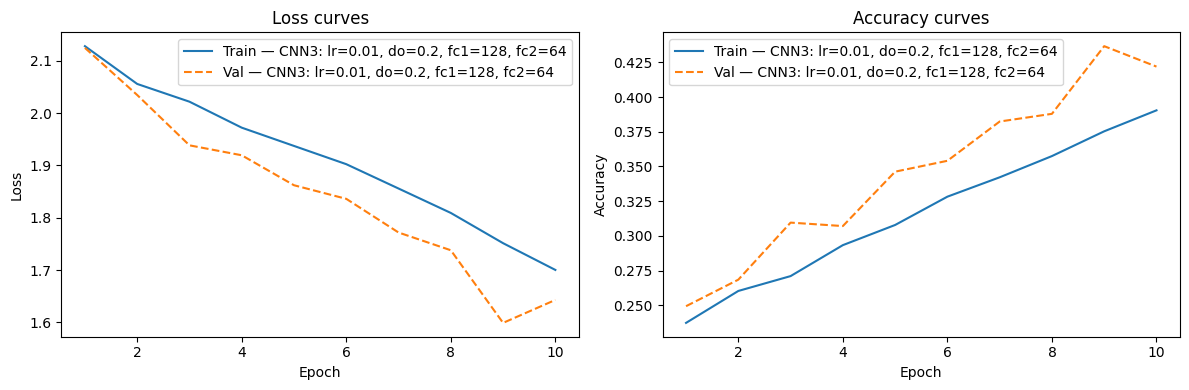

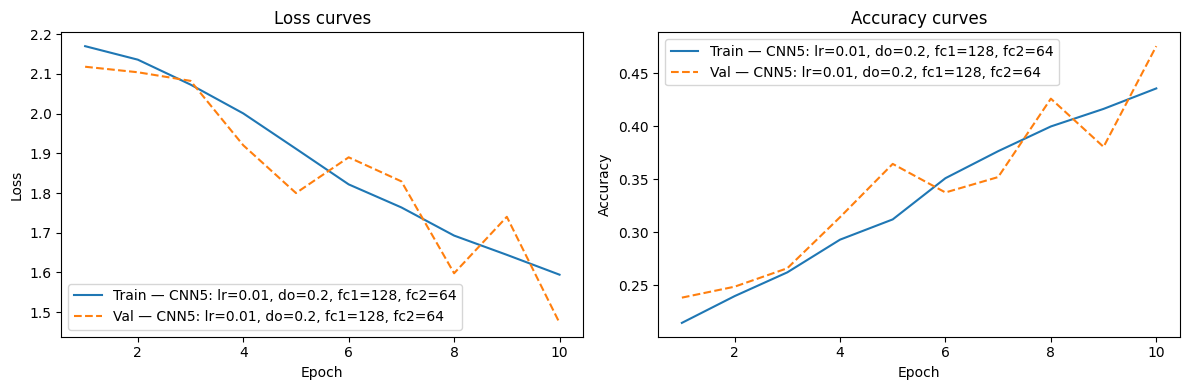

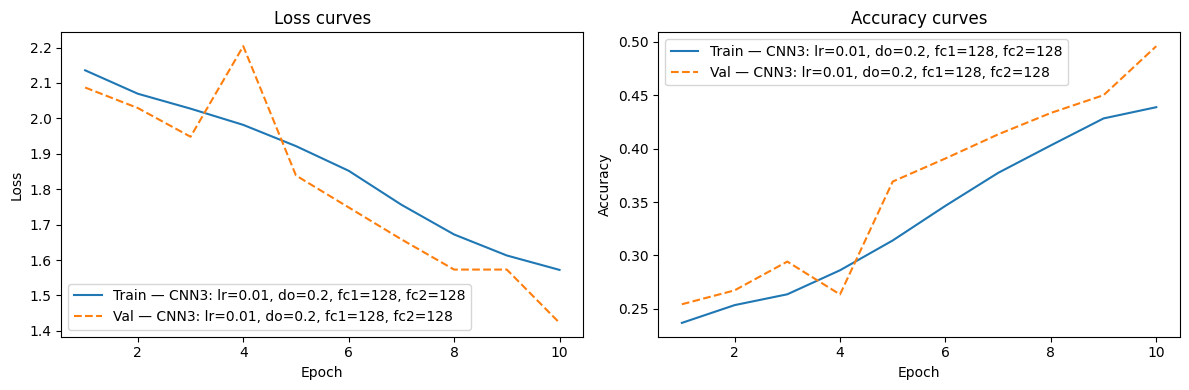

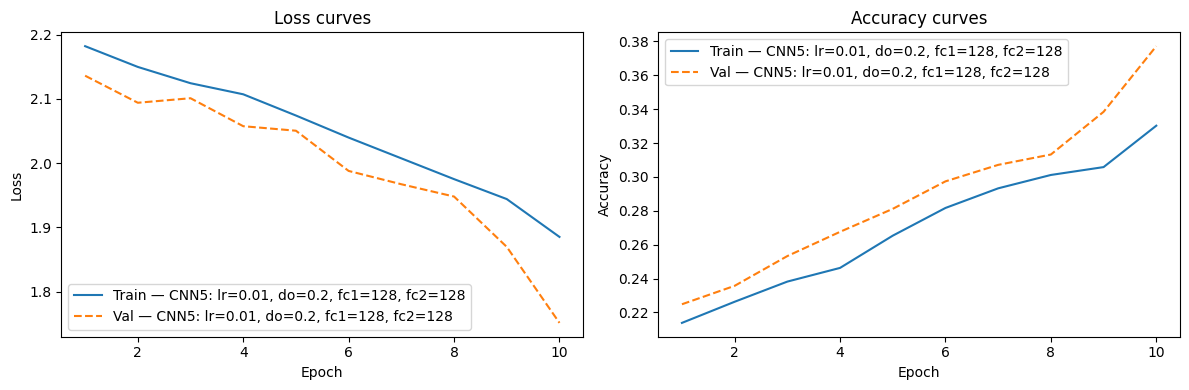

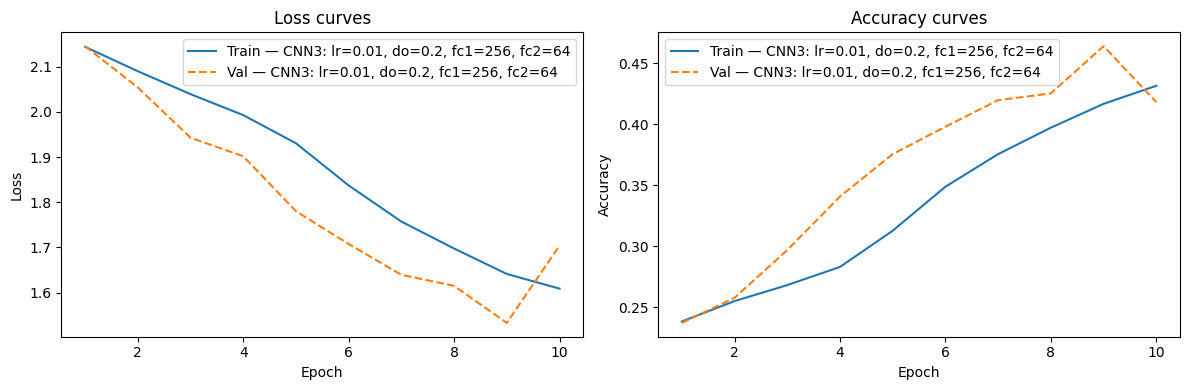

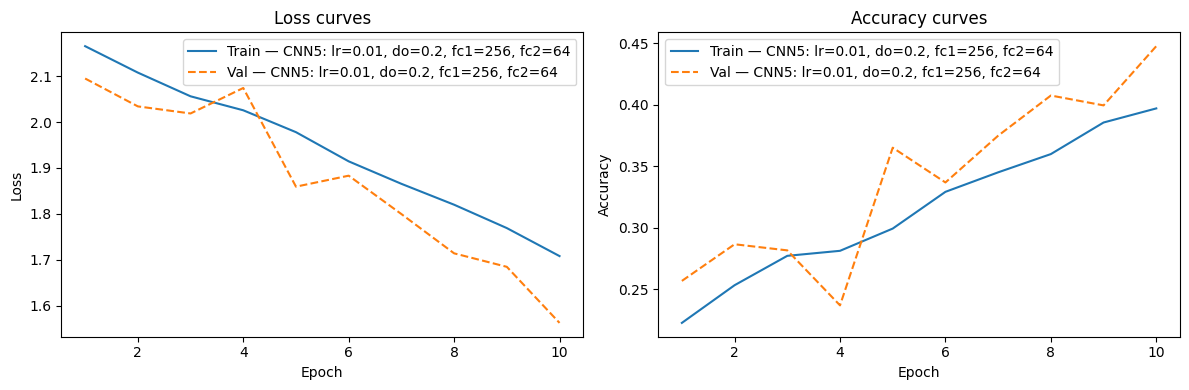

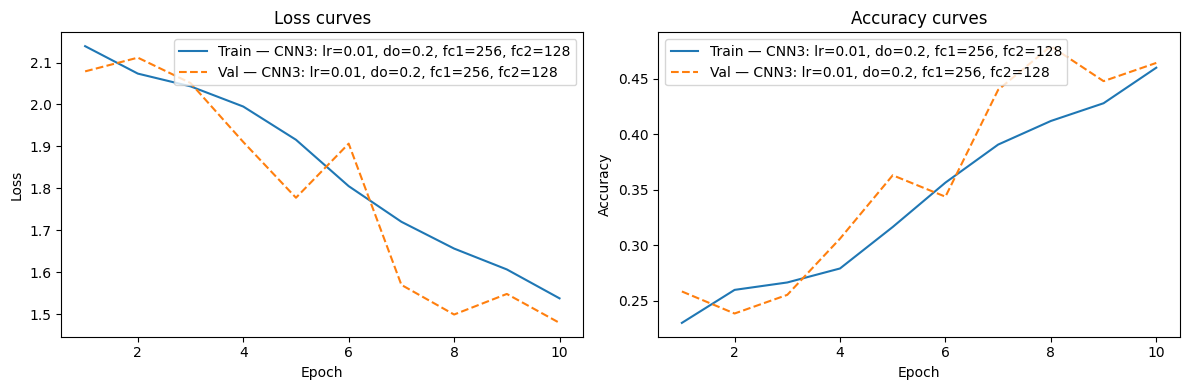

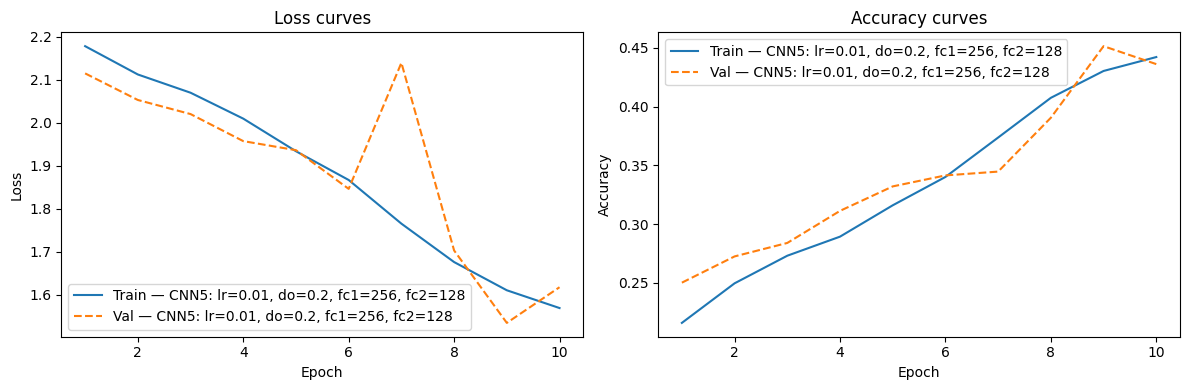

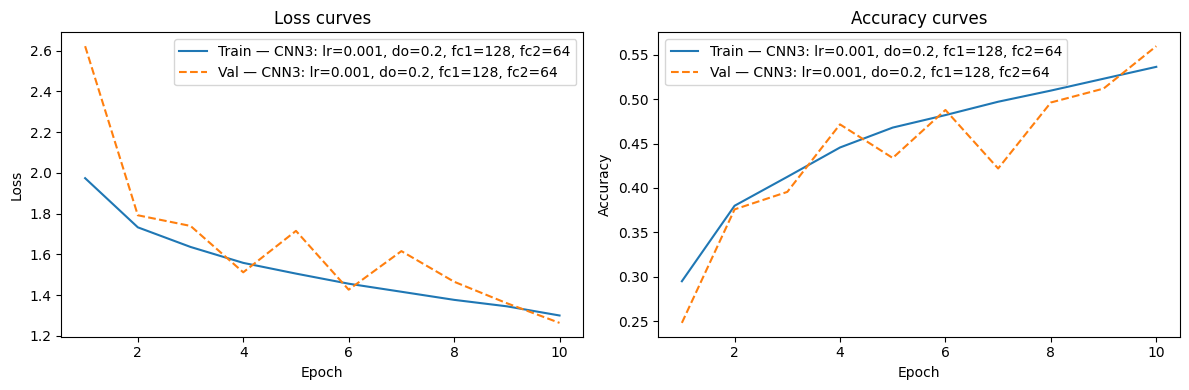

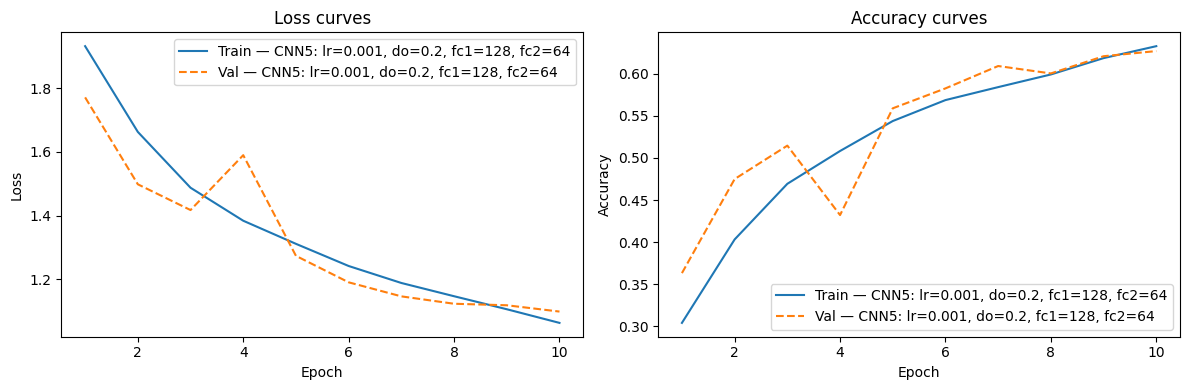

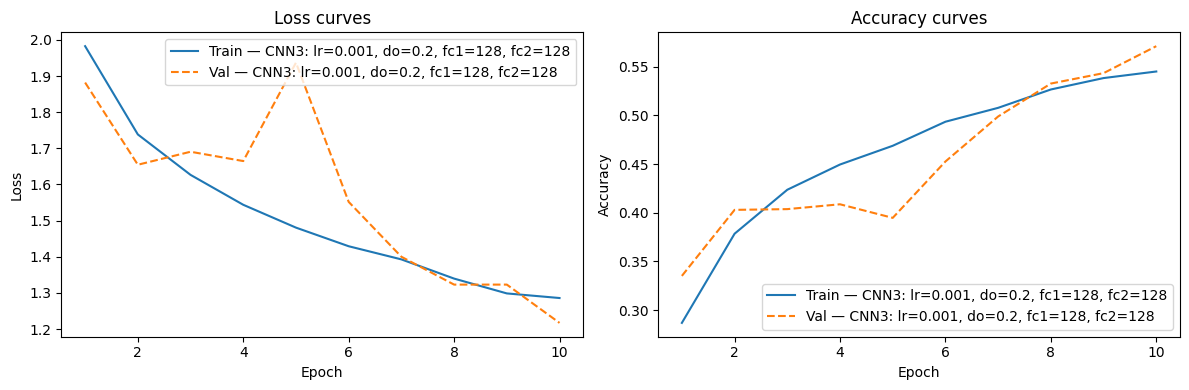

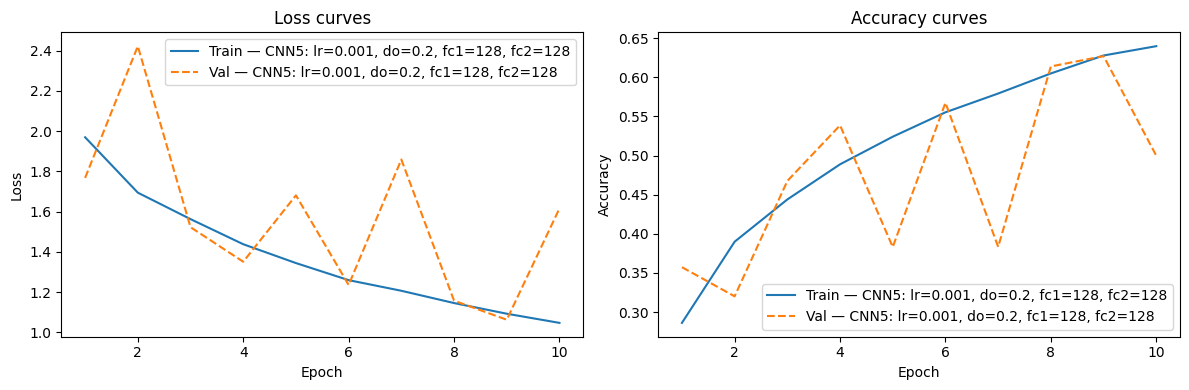

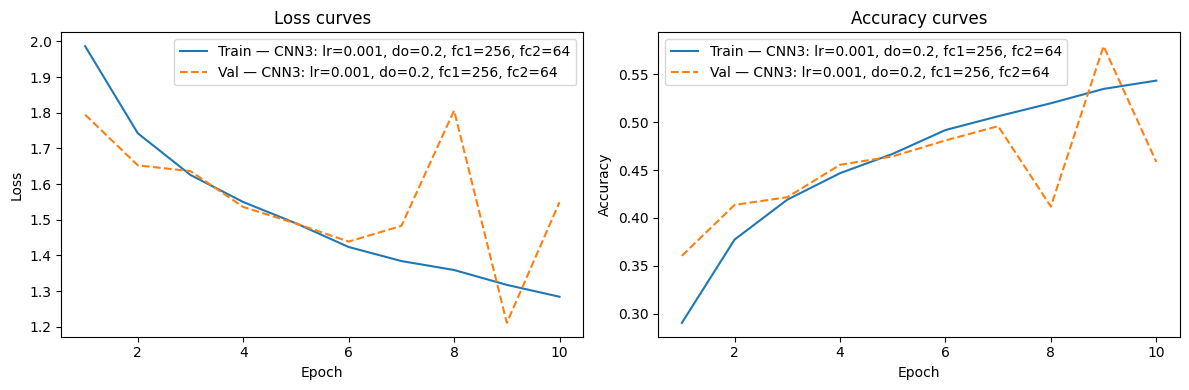

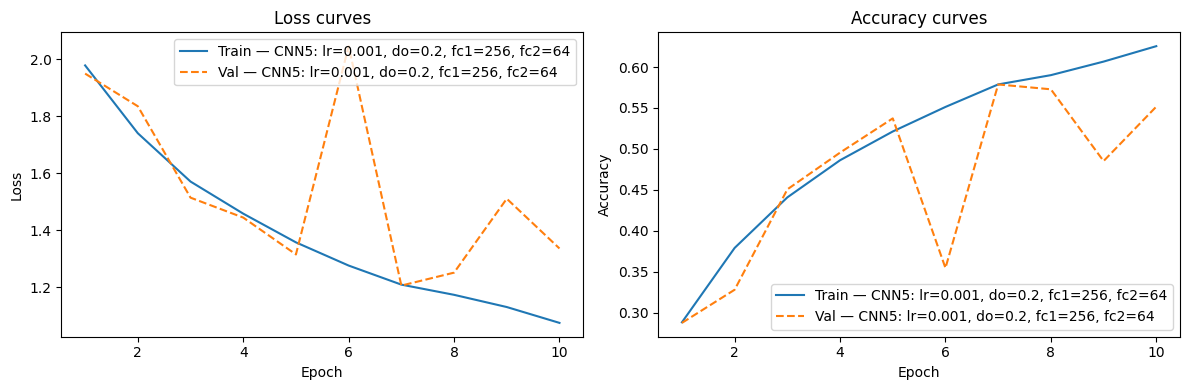

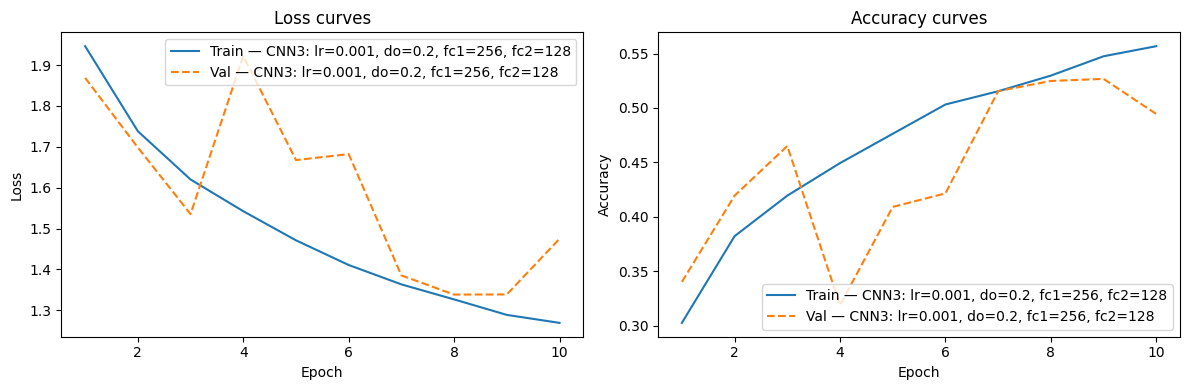

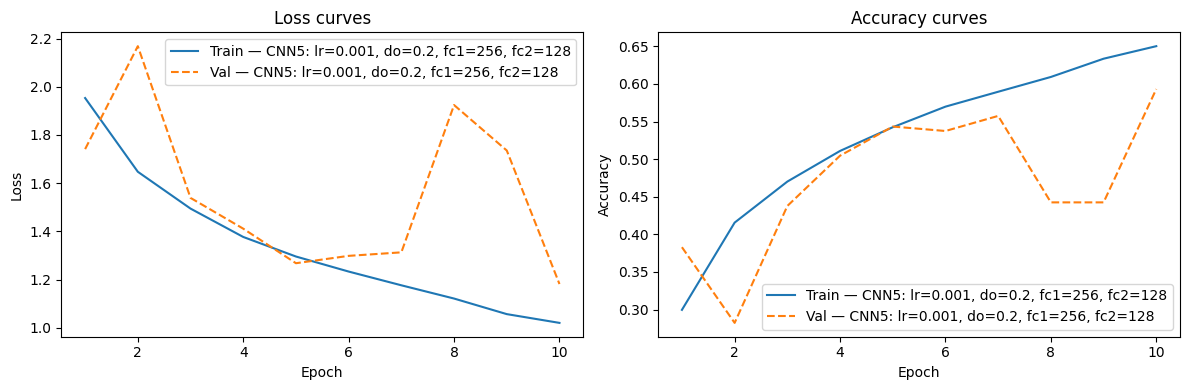

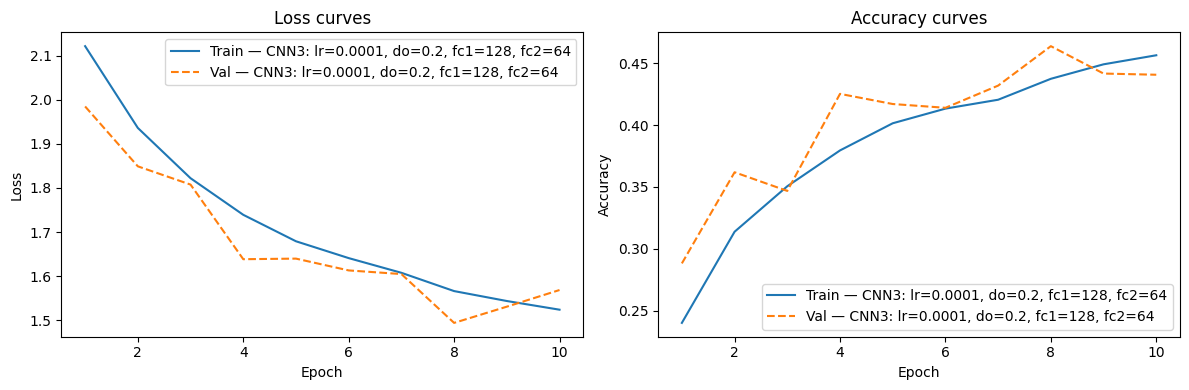

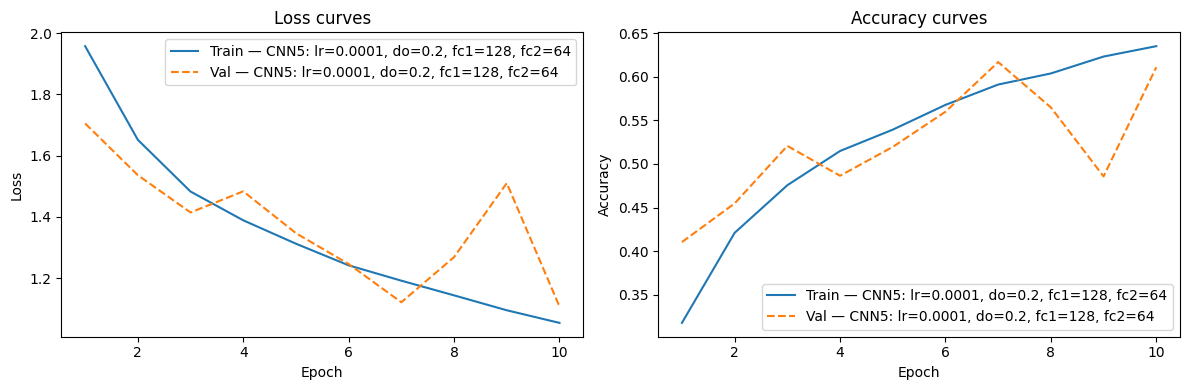

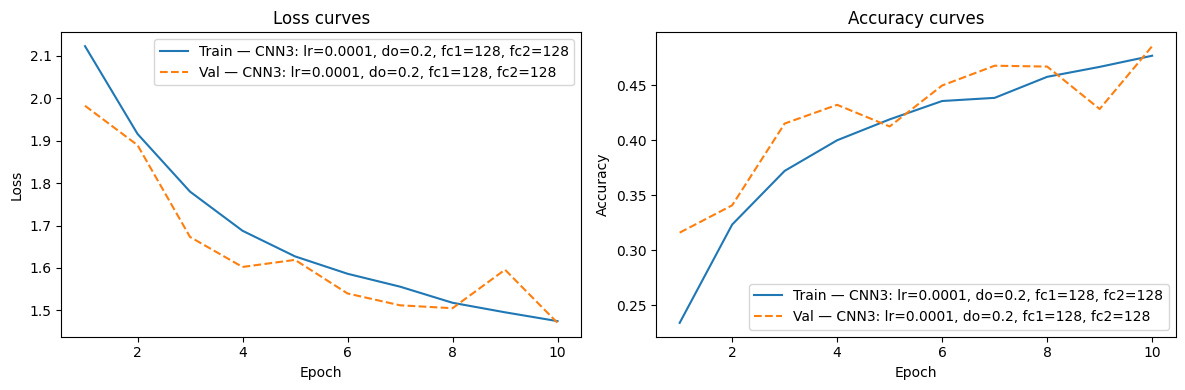

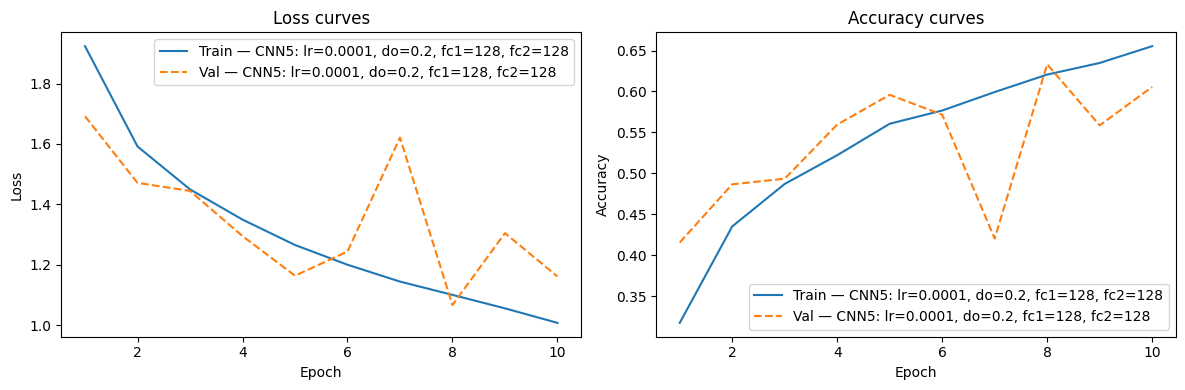

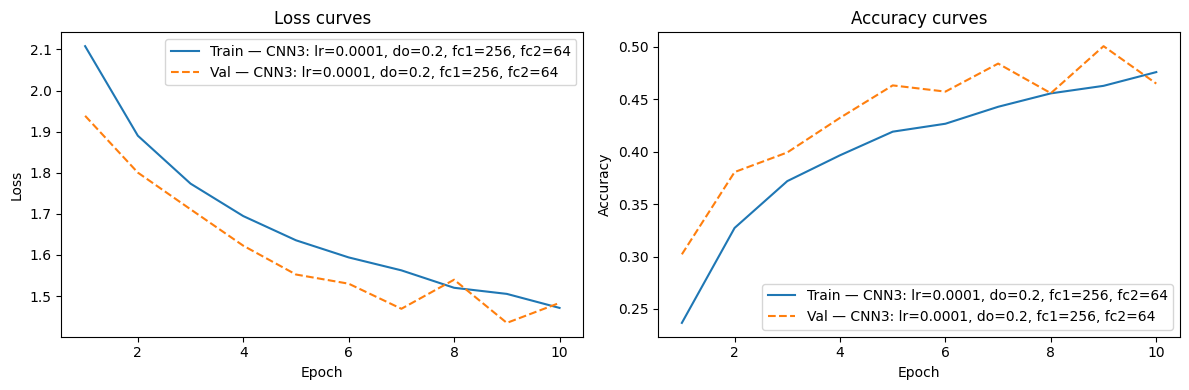

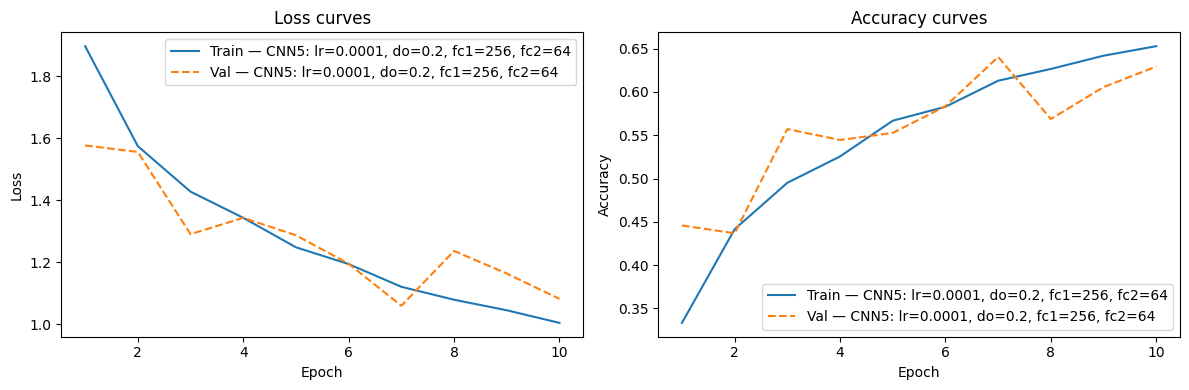

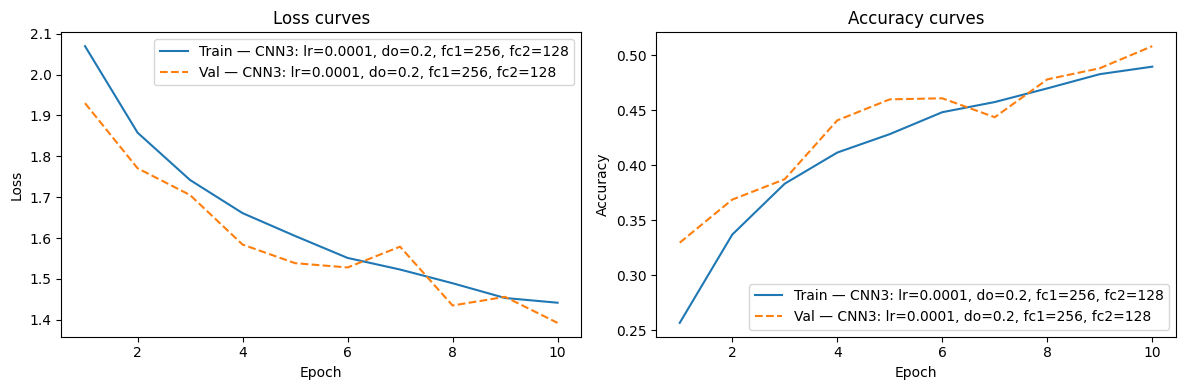

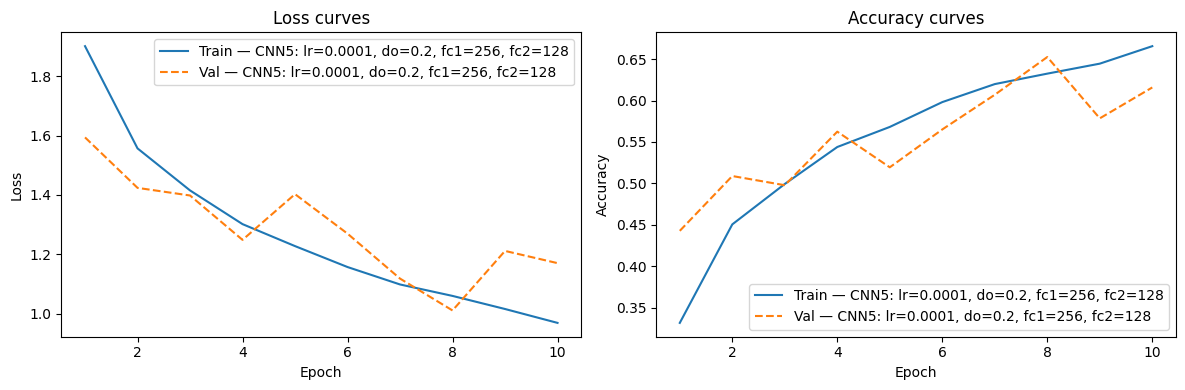

In [40]:
plot_training_curves(histories)

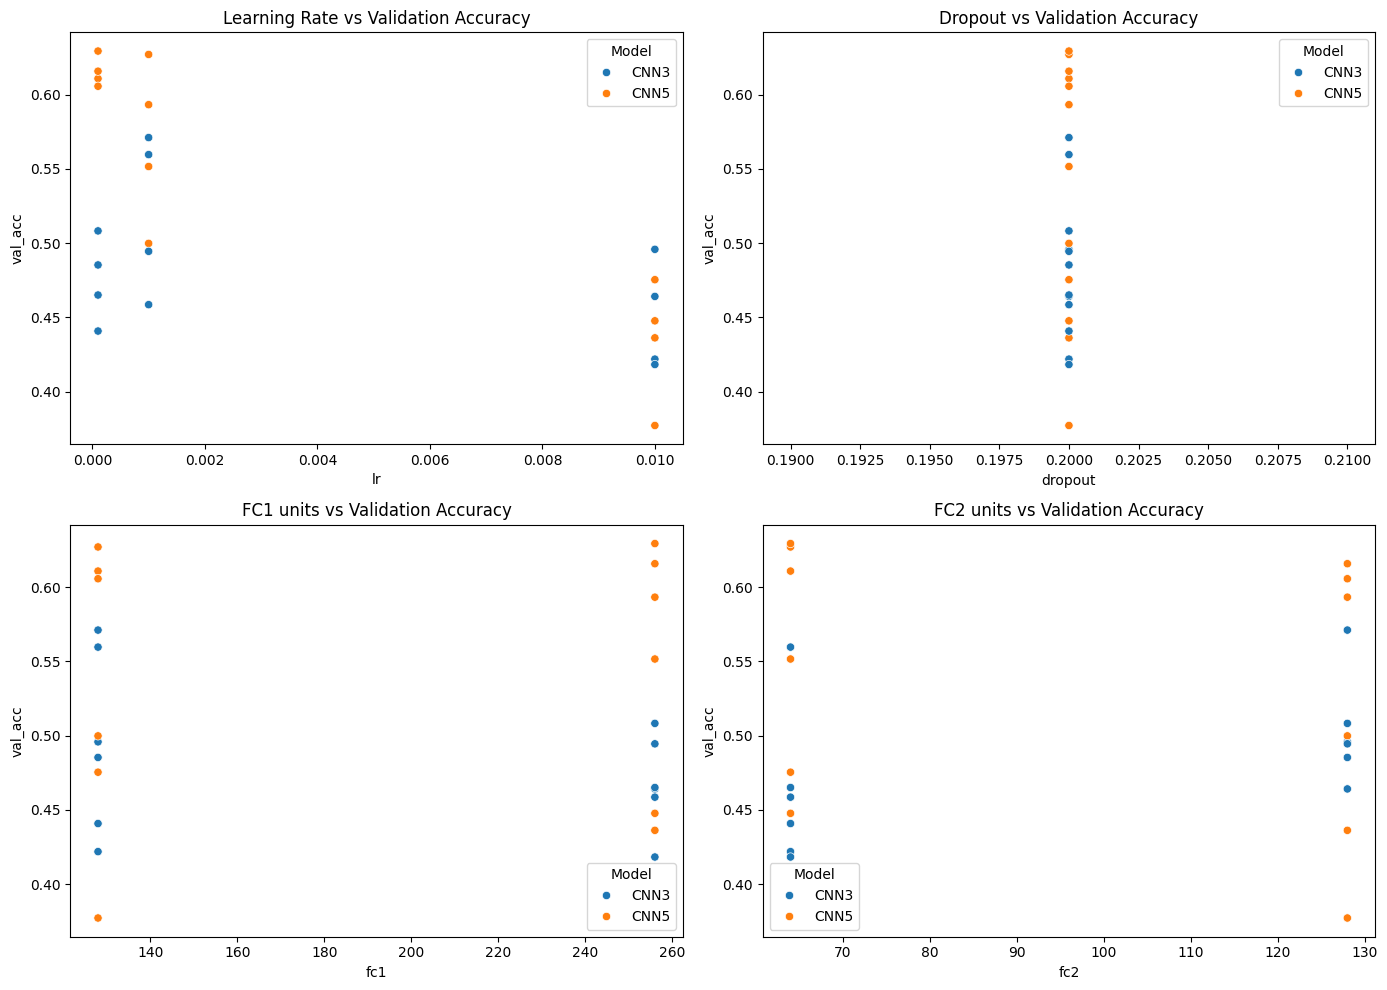

In [41]:
plot_hparam_vs_accuracy(df_results)

# **Автоматична оптимізація**

In [42]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 23.9 MB/s eta 0:00:00


In [47]:
import optuna
from optuna.trial import Trial

def make_objective_from_combinations(combinations, train_loader, val_loader, device, epochs):
    def objective(trial):
        idx = trial.suggest_int('combo_index', 0, len(combinations) - 1)
        lr, dropout, fc1, fc2, (model_name, ModelClass) = combinations[idx]

        print(f"Optuna Trial | Combo {idx}: "
              f"lr={lr}, dropout={dropout}, fc1={fc1}, fc2={fc2}, model={model_name}")

        model = ModelClass(fc1_units=fc1, fc2_units=fc2, dropout=dropout).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        for _ in range(epochs):
            train_one_epoch(model, train_loader, criterion, optimizer, device)

        val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)
        return val_f1
    return objective

In [48]:
search_space = {'combo_index': list(range(len(combinations)))}
sampler = optuna.samplers.GridSampler(search_space)

study = optuna.create_study(direction='maximize', sampler=sampler)

[I 2025-04-30 12:40:02,016] A new study created in memory with name: no-name-97f3e72e-cfa0-43da-b41f-1104b3182348


In [49]:
objective = make_objective_from_combinations(
    combinations, train_loader, val_loader, device, epochs=5
)

study.optimize(objective, n_trials=len(combinations))

Optuna Trial | Combo 11: lr=0.001, dropout=0.2, fc1=128, fc2=128, model=CNN5


[I 2025-04-30 12:42:13,091] Trial 0 finished with value: 0.5361538295633415 and parameters: {'combo_index': 11}. Best is trial 0 with value: 0.5361538295633415.


Optuna Trial | Combo 10: lr=0.001, dropout=0.2, fc1=128, fc2=128, model=CNN3


[I 2025-04-30 12:44:22,578] Trial 1 finished with value: 0.4162849654204631 and parameters: {'combo_index': 10}. Best is trial 0 with value: 0.5361538295633415.


Optuna Trial | Combo 22: lr=0.0001, dropout=0.2, fc1=256, fc2=128, model=CNN3


...

[I 2025-04-30 13:27:25,211] Trial 21 finished with value: 0.5424871216816034 and parameters: {'combo_index': 21}. Best is trial 7 with value: 0.5728577588009769.


Optuna Trial | Combo 15: lr=0.001, dropout=0.2, fc1=256, fc2=128, model=CNN5


[I 2025-04-30 13:29:34,537] Trial 22 finished with value: 0.47926263837081906 and parameters: {'combo_index': 15}. Best is trial 7 with value: 0.5728577588009769.


Optuna Trial | Combo 12: lr=0.001, dropout=0.2, fc1=256, fc2=64, model=CNN3


[I 2025-04-30 13:31:43,966] Trial 23 finished with value: 0.47218316538961924 and parameters: {'combo_index': 12}. Best is trial 7 with value: 0.5728577588009769.


In [50]:
best_trial = study.best_trial

print("Найкращий результат:")
print(f"Номер спроби: {best_trial.number}")
print(f"Гіперпараметри: {best_trial.params}")
print(f"Val F1-score: {best_trial.value:.4f}")

Найкращий результат:
Номер спроби: 7
Гіперпараметри: {'combo_index': 23}
Val F1-score: 0.5729


In [51]:
best_idx = best_trial.params['combo_index']
best_params = combinations[best_idx]
best_params

(0.0001, 0.2, 256, 128, ('CNN5', __main__.CNN5))

In [52]:
lr, dropout, fc1, fc2, (model_name, ModelClass) = best_params

best_model_record = {
    'trial_number': best_trial.number,
    'combo_index': best_idx,
    'architecture': model_name,
    'lr': lr,
    'dropout': dropout,
    'fc1_units': fc1,
    'fc2_units': fc2,
    'val_f1': best_trial.value
}

best_df = pd.DataFrame([best_model_record])
best_df.to_csv('best_optuna_result.csv', index=False)

# **Тренування моделей**

Модель з найкращими параметрами автоматичного підбору

In [53]:
best_model_optuna = ModelClass(fc1_units=fc1, fc2_units=fc2, dropout=dropout).to(device)

optimizer_optuna = torch.optim.Adam(best_model_optuna.parameters(), lr=lr)
criterion_optuna = torch.nn.CrossEntropyLoss()
epochs = 20

In [54]:
train_losses_optuna, val_losses_optuna = [], []
train_accuracies_optuna, val_accuracies_optuna = [], []
val_f1_scores_optuna = []

In [55]:
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(best_model_optuna, train_loader, criterion_optuna, optimizer_optuna, device)
    val_loss, val_acc, val_f1 = validate_one_epoch(best_model_optuna, val_loader, criterion_optuna, device)

    train_losses_optuna.append(train_loss)
    val_losses_optuna.append(val_loss)
    train_accuracies_optuna.append(train_acc)
    val_accuracies_optuna.append(val_acc)
    val_f1_scores_optuna.append(val_f1)

    print(f"Epoch [{epoch+1}/{epochs}] — "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

test_loss_optuna, test_acc_optuna, test_f1_optuna = test_evaluate(best_model_optuna, test_loader, criterion_optuna, device)

print("\nТестова оцінка моделі з параметрів Optuna:")
print(f"Test Loss: {test_loss_optuna:.4f}, Accuracy: {test_acc_optuna:.4f}, F1-score: {test_f1_optuna:.4f}")

Epoch [1/20] — Train Loss: 1.8838, Acc: 0.3364 | Val Loss: 1.7693, Acc: 0.3764, F1: 0.3078
Epoch [2/20] — Train Loss: 1.5435, Acc: 0.4525 | Val Loss: 1.4272, Acc: 0.4914, F1: 0.4613
Epoch [3/20] — Train Loss: 1.3941, Acc: 0.5107 | Val Loss: 1.3362, Acc: 0.5460, F1: 0.5269
Epoch [4/20] — Train Loss: 1.2891, Acc: 0.5510 | Val Loss: 1.2029, Acc: 0.5842, F1: 0.5722
Epoch [5/20] — Train Loss: 1.2111, Acc: 0.5776 | Val Loss: 1.3029, Acc: 0.5495, F1: 0.5285
Epoch [6/20] — Train Loss: 1.1403, Acc: 0.6055 | Val Loss: 1.1341, Acc: 0.6033, F1: 0.5847
Epoch [7/20] — Train Loss: 1.0908, Acc: 0.6221 | Val Loss: 1.3520, Acc: 0.5309, F1: 0.5042
Epoch [8/20] — Train Loss: 1.0496, Acc: 0.6369 | Val Loss: 1.1309, Acc: 0.6140, F1: 0.6095
Epoch [9/20] — Train Loss: 1.0175, Acc: 0.6495 | Val Loss: 1.1368, Acc: 0.6178, F1: 0.5923
Epoch [10/20] — Train Loss: 0.9725, Acc: 0.6609 | Val Loss: 1.1422, Acc: 0.6071, F1: 0.5850
Epoch [11/20] — Train Loss: 0.9343, Acc: 0.6796 | Val Loss: 0.9574, Acc: 0.6684, F1: 0.66

In [56]:
torch.save(best_model_optuna.state_dict(), "best_model_optuna.pth")

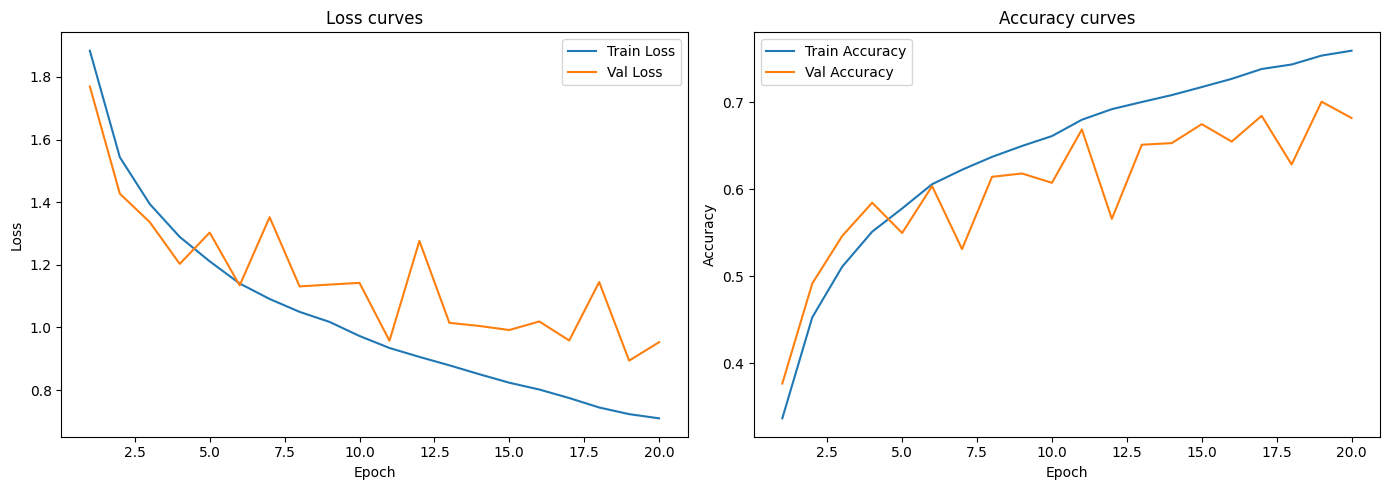

In [58]:
epochs = range(1, 21)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_optuna, label='Train Loss')
plt.plot(epochs, val_losses_optuna, label='Val Loss')
plt.title('Loss curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies_optuna, label='Train Accuracy')
plt.plot(epochs, val_accuracies_optuna, label='Val Accuracy')
plt.title('Accuracy curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Модель з найкращими параметрами ручного підбору

In [59]:
manual_best = best_model
lr = manual_best['lr']
dropout = manual_best['dropout']
fc1 = manual_best['fc1']
fc2 = manual_best['fc2']
model_name = manual_best['Model']
ModelClass = cnn_classes[model_name]

best_manual_model = ModelClass(fc1_units=fc1, fc2_units=fc2, dropout=dropout).to(device)

optimizer_manual = torch.optim.Adam(best_manual_model.parameters(), lr=lr)
criterion_manual = torch.nn.CrossEntropyLoss()
epochs = 20

train_losses_manual, val_losses_manual = [], []
train_accuracies_manual, val_accuracies_manual = [], []
val_f1_scores_manual = []

In [60]:
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(best_manual_model, train_loader, criterion_manual, optimizer_manual, device)
    val_loss, val_acc, val_f1 = validate_one_epoch(best_manual_model, val_loader, criterion_manual, device)

    train_losses_manual.append(train_loss)
    val_losses_manual.append(val_loss)
    train_accuracies_manual.append(train_acc)
    val_accuracies_manual.append(val_acc)
    val_f1_scores_manual.append(val_f1)

    print(f"Epoch [{epoch+1}/{epochs}] — "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

test_loss_manual, test_acc_manual, test_f1_manual = test_evaluate(best_manual_model, test_loader, criterion_manual, device)

print("\nТестова оцінка моделі з ручного перебору:")
print(f"Test Loss: {test_loss_manual:.4f}, Accuracy: {test_acc_manual:.4f}, F1-score: {test_f1_manual:.4f}")

Epoch [1/20] — Train Loss: 1.9388, Acc: 0.3139 | Val Loss: 1.8562, Acc: 0.3581, F1: 0.2850
Epoch [2/20] — Train Loss: 1.6590, Acc: 0.4075 | Val Loss: 2.1231, Acc: 0.3604, F1: 0.2811
Epoch [3/20] — Train Loss: 1.4984, Acc: 0.4691 | Val Loss: 1.7051, Acc: 0.4158, F1: 0.3764
Epoch [4/20] — Train Loss: 1.3770, Acc: 0.5120 | Val Loss: 1.7314, Acc: 0.4326, F1: 0.3540
Epoch [5/20] — Train Loss: 1.2801, Acc: 0.5479 | Val Loss: 1.6269, Acc: 0.4742, F1: 0.4033
Epoch [6/20] — Train Loss: 1.2339, Acc: 0.5637 | Val Loss: 1.4732, Acc: 0.5126, F1: 0.4696
Epoch [7/20] — Train Loss: 1.1698, Acc: 0.5906 | Val Loss: 1.5312, Acc: 0.4780, F1: 0.4455
Epoch [8/20] — Train Loss: 1.1287, Acc: 0.6052 | Val Loss: 1.1472, Acc: 0.6115, F1: 0.5990
Epoch [9/20] — Train Loss: 1.0730, Acc: 0.6279 | Val Loss: 1.2632, Acc: 0.5670, F1: 0.5517
Epoch [10/20] — Train Loss: 1.0325, Acc: 0.6421 | Val Loss: 0.9786, Acc: 0.6719, F1: 0.6539
Epoch [11/20] — Train Loss: 0.9843, Acc: 0.6593 | Val Loss: 1.5302, Acc: 0.5294, F1: 0.54

In [61]:
torch.save(best_manual_model.state_dict(), "best_manual_model.pth")

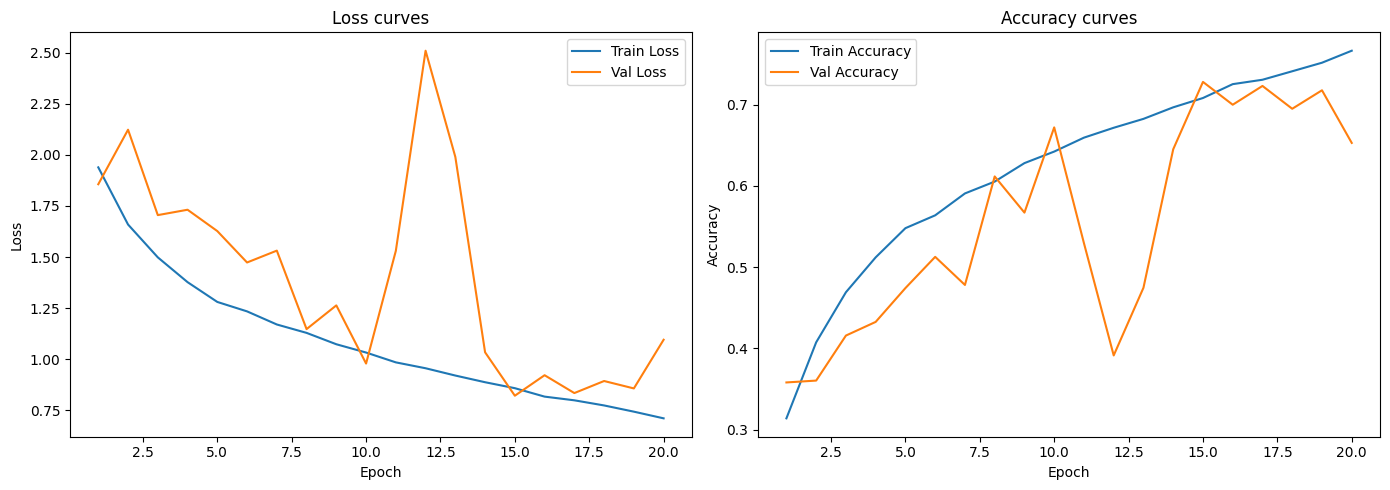

In [70]:
epochs = range(1, 21)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_manual, label='Train Loss')
plt.plot(epochs, val_losses_manual, label='Val Loss')
plt.title('Loss curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies_manual, label='Train Accuracy')
plt.plot(epochs, val_accuracies_manual, label='Val Accuracy')
plt.title('Accuracy curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Модель з минулої роботи (20 епох)

In [78]:
model2 = CNN()

In [79]:
model2.load_state_dict(torch.load(f'/content/model2.pth'))
model2.eval()
model2.to(device)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fals

In [80]:
criterion = torch.nn.CrossEntropyLoss()
test_loss2, test_acc2, test_f12 = test_evaluate(model2, test_loader, criterion, device)

print("\nТестові результати:")
print(f"Loss: {test_loss2:.4f}, Accuracy: {test_acc2:.4f}, F1-score: {test_f12:.4f}")


Тестові результати:
Loss: 0.8898, Accuracy: 0.7328, F1-score: 0.7179


Модель з минулої роботи (25 епох)

In [81]:
model2_25 = CNN()

In [82]:
model2_25.load_state_dict(torch.load(f'/content/model2_25.pth'))
model2_25.eval()
model2_25.to(device)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fals

In [83]:
criterion = torch.nn.CrossEntropyLoss()
test_loss2_25, test_acc2_25, test_f12_25 = test_evaluate(model2_25, test_loader, criterion, device)

print("\nТестові результати:")
print(f"Loss: {test_loss2_25:.4f}, Accuracy: {test_acc2_25:.4f}, F1-score: {test_f12_25:.4f}")


Тестові результати:
Loss: 0.5855, Accuracy: 0.8178, F1-score: 0.8179


In [84]:
comparison_df = pd.DataFrame([
    {
        'Назва моделі': 'Оптимізована (Optuna)',
        'Test Loss': test_loss_optuna,
        'Test Accuracy': test_acc_optuna,
        'Test F1-score': test_f1_optuna
    },
    {
        'Назва моделі': 'Ручний підбір',
        'Test Loss': test_loss_manual,
        'Test Accuracy': test_acc_manual,
        'Test F1-score': test_f1_manual
    },
    {
        'Назва моделі': 'Завантажена з файлу 2 (20 епох)',
        'Test Loss': test_loss2,
        'Test Accuracy': test_acc2,
        'Test F1-score': test_f12
    },
    {
        'Назва моделі': 'Завантажена з файлу 2 (25 епох)',
        'Test Loss': test_loss2_25,
        'Test Accuracy': test_acc2_25,
        'Test F1-score': test_f12_25
    }
])

comparison_df

,Назва моделі,Test Loss,Test Accuracy,Test F1-score
0,Оптимізована (Optuna),0.943709,0.690031,0.688057
1,Ручний підбір,1.089211,0.666730,0.665442
2,Завантажена з файлу 2 (20 епох),0.889849,0.732811,0.717929
3,Завантажена з файлу 2 (25 епох),0.585474,0.817800,0.817870


In [85]:
lr, dropout, fc1, fc2, (model_name, _) = best_params

optuna_row = {
    'Model': model_name,
    'lr': lr,
    'dropout': dropout,
    'fc1': fc1,
    'fc2': fc2,
    'val_acc': val_accuracies_optuna[-1] if val_accuracies_optuna else None,
    'val_f1': val_f1_scores_optuna[-1] if val_f1_scores_optuna else None,
    'test_acc': test_acc_optuna,
    'test_f1': test_f1_optuna
}

In [86]:
manual_row = {
    'Model': manual_best['Model'],
    'lr': manual_best['lr'],
    'dropout': manual_best['dropout'],
    'fc1': manual_best['fc1'],
    'fc2': manual_best['fc2'],
    'val_acc': manual_best['val_acc'],
    'val_f1': manual_best['val_f1'],
    'test_acc': manual_best['test_acc'],
    'test_f1': manual_best['test_f1']
}

In [98]:
model2_row = {
    'Model': 'CNN (20 епох)',
    'lr': 0.001,
    'dropout': 0.2,
    'fc1': 256,
    'fc2': 128,
    'val_acc': 0.8050,
    'val_f1': 0.8046,
    'test_acc': test_acc2,
    'test_f1': test_f12
}

In [99]:
model2_25_row = {
    'Model': 'CNN (25 епох)',
    'lr': 0.001,
    'dropout': 0.2,
    'fc1': 256,
    'fc2': 128,
    'val_acc': 0.7164,
    'val_f1': 0.7007,
    'test_acc': test_acc2_25,
    'test_f1': test_f12_25
}

In [100]:
full_results_df = pd.DataFrame([optuna_row, manual_row, model2_row, model2_25_row])

full_results_df

,Model,lr,dropout,fc1,fc2,val_acc,val_f1,test_acc,test_f1
0,CNN5,0.0001,0.2,256,128,0.681627,0.680513,0.690031,0.688057
1,CNN5,0.0010,0.2,128,64,0.627005,0.632701,0.631207,0.635776
2,CNN (20 епох),0.0010,0.2,256,128,0.805000,0.804600,0.732811,0.717929
3,CNN (25 епох),0.0010,0.2,256,128,0.716400,0.700700,0.817800,0.817870


In [101]:
full_results_df.to_csv('full_results.csv', index=False)

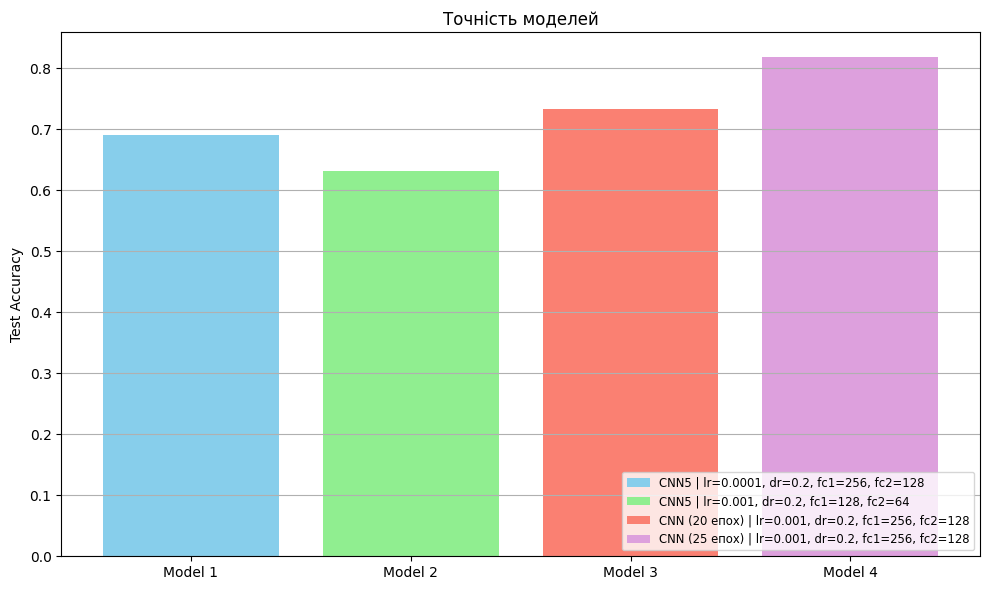

In [116]:
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']

plt.figure(figsize=(10, 6))

bars = plt.bar(range(len(full_results_df)), full_results_df["test_acc"], color=colors)

legend_labels = [
    f"{row.Model} | lr={row.lr}, dr={row.dropout}, fc1={row.fc1}, fc2={row.fc2}"
    for _, row in full_results_df.iterrows()
]

for bar, label in zip(bars, legend_labels):
    bar.set_label(label)

plt.legend(loc="lower right", fontsize='small')
plt.xticks(range(len(full_results_df)), [f"Model {i + 1}" for i in range(len(full_results_df))])
plt.ylabel("Test Accuracy")
plt.title("Точність моделей")
plt.tight_layout()
plt.grid(axis='y')
plt.show()
